# Student Performance Analysis & Prediction
**Dataset:** 15 students | **Tasks:** Pandas · Matplotlib · Seaborn · scikit-learn

This notebook loads student score data, explores it with pandas, visualises patterns with Matplotlib and Seaborn, then builds a Logistic Regression model to predict whether a student passes or fails.

---
## Imports
All libraries are imported in one place at the top so they are easy to find.

In [3]:
# pandas - used for loading and exploring the dataset
# matplotlib - used for all basic plots (bar, histogram, scatter, box, line)
# seaborn - used for statistical plots on top of matplotlib
# sklearn - used for the machine learning model and preprocessing

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Task 1 — Data Exploration with Pandas

### 1.1 Load the dataset and print first 5 rows

In [6]:
# load students.csv into a pandas DataFrame
df = pd.read_csv("students.csv")

# subject_cols is used throughout the notebook wherever we need just the 5 subjects
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# head() shows the first 5 rows so we can quickly check the data loaded correctly
print("First 5 rows:")
print(df.head())

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


### 1.2 Shape and data types

In [8]:
# shape returns (rows, columns) so we know how big the dataset is
print("Shape (rows x columns):", df.shape)

# dtypes shows what type of data each column holds
# int64 = whole number, float64 = decimal, object = text
print("")
print("Data types:")
print(df.dtypes)

Shape (rows x columns): (15, 9)

Data types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


### 1.3 Summary statistics

In [10]:
# describe() automatically calculates count, mean, std, min, 25%, 50%, 75%, max
# for every numeric column in the DataFrame
print("Summary statistics:")
print(df.describe())

Summary statistics:
            math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%               2

### 1.4 Pass / Fail counts

In [12]:
# value_counts() counts how many times each unique value appears
# in the passed column: 1 = Pass, 0 = Fail
print("Pass / Fail counts:")
print(df['passed'].value_counts())
print("")
print("9 students passed, 6 students failed out of 15 total.")

Pass / Fail counts:
passed
1    9
0    6
Name: count, dtype: int64

9 students passed, 6 students failed out of 15 total.


### 1.5 Average scores — passing vs failing students

In [14]:
# filter the DataFrame by the passed column first, then take the mean
# df[df['passed'] == 1] gives us only the rows where passed equals 1
# then [subject_cols] selects only the 5 subject columns
# then .mean() calculates the average for each subject

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("Average scores for PASSING students:")
print(pass_avg.round(2))
print("")
print("Average scores for FAILING students:")
print(fail_avg.round(2))

Average scores for PASSING students:
math       78.22
science    78.56
english    79.11
history    73.44
pe         86.00
dtype: float64

Average scores for FAILING students:
math       45.17
science    49.00
english    46.83
history    48.33
pe         58.00
dtype: float64


### 1.6 Student with the highest overall average

In [16]:
# mean(axis=1) calculates the average across columns (row-wise) for each student
# we store it in a new avg_score column so we can also use it in Task 2
df['avg_score'] = df[subject_cols].mean(axis=1)

# idxmax() returns the index (row number) of the highest value in the column
top_idx = df['avg_score'].idxmax()

print("Student with highest overall average:")
print(df.loc[top_idx, 'name'], "with an average of", round(df.loc[top_idx, 'avg_score'], 2))

Student with highest overall average:
Diana with an average of 94.0


---
## Task 2 — Data Visualization with Matplotlib

Five plots — each saved as a `.png` and displayed inline. Every plot has a title, labelled axes, and a legend where relevant.

### Plot 1 — Bar Chart: Average Score Per Subject

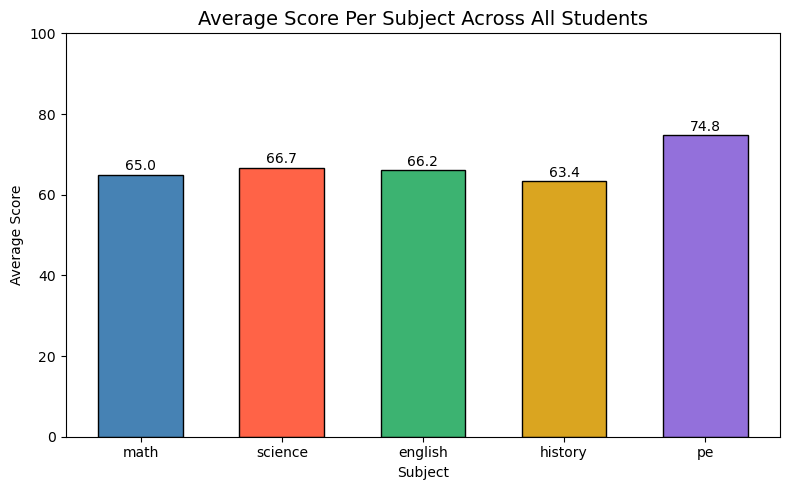

Saved: plot1_bar.png


In [19]:
# bar chart — one bar per subject showing the average score across all 15 students

fig, ax = plt.subplots(figsize=(8, 5))

# calculate the mean for each subject
subject_means = df[subject_cols].mean()

# give each bar a different colour so they are easy to tell apart
colors = ['steelblue', 'tomato', 'mediumseagreen', 'goldenrod', 'mediumpurple']
bars = ax.bar(subject_cols, subject_means, color=colors, edgecolor='black', width=0.6)

# add a value label on top of each bar
for bar, val in zip(bars, subject_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(round(val, 1)), ha='center', fontsize=10)

ax.set_title('Average Score Per Subject Across All Students', fontsize=14)
ax.set_xlabel('Subject')
ax.set_ylabel('Average Score')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('plot1_bar.png', dpi=100)
plt.show()
print("Saved: plot1_bar.png")

### Plot 2 — Histogram: Distribution of Math Scores

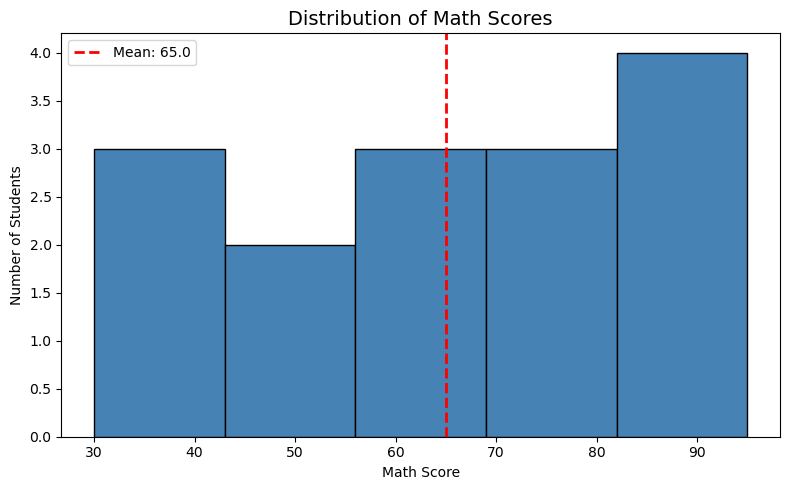

Saved: plot2_histogram.png


In [21]:
# histogram with 5 bins — each bin covers a range of math scores
# taller bars mean more students scored in that range

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df['math'], bins=5, color='steelblue', edgecolor='black')

# add a vertical dashed line at the mean so we can see where the average sits
mean_math = df['math'].mean()
ax.axvline(mean_math, color='red', linestyle='--', linewidth=2,
           label='Mean: ' + str(round(mean_math, 1)))

ax.set_title('Distribution of Math Scores', fontsize=14)
ax.set_xlabel('Math Score')
ax.set_ylabel('Number of Students')
ax.legend()

plt.tight_layout()
plt.savefig('plot2_histogram.png', dpi=100)
plt.show()
print("Saved: plot2_histogram.png")

### Plot 3 — Scatter Plot: Study Hours vs Average Score

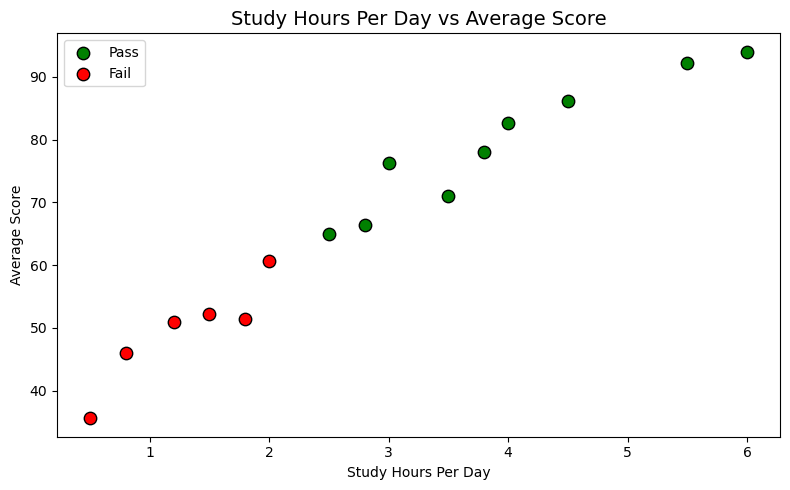

Saved: plot3_scatter.png


In [23]:
# scatter plot — each dot is one student
# colour tells us if they passed (green) or failed (red)
# we plot the two groups separately using two plt.scatter() calls

fig, ax = plt.subplots(figsize=(8, 5))

pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

# plot passing students first, then failing students on the same axes
ax.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'],
           color='green', label='Pass', s=80, edgecolors='black')
ax.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'],
           color='red', label='Fail', s=80, edgecolors='black')

ax.set_title('Study Hours Per Day vs Average Score', fontsize=14)
ax.set_xlabel('Study Hours Per Day')
ax.set_ylabel('Average Score')
ax.legend()

plt.tight_layout()
plt.savefig('plot3_scatter.png', dpi=100)
plt.show()
print("Saved: plot3_scatter.png")

### Plot 4 — Box Plot: Attendance % by Pass / Fail

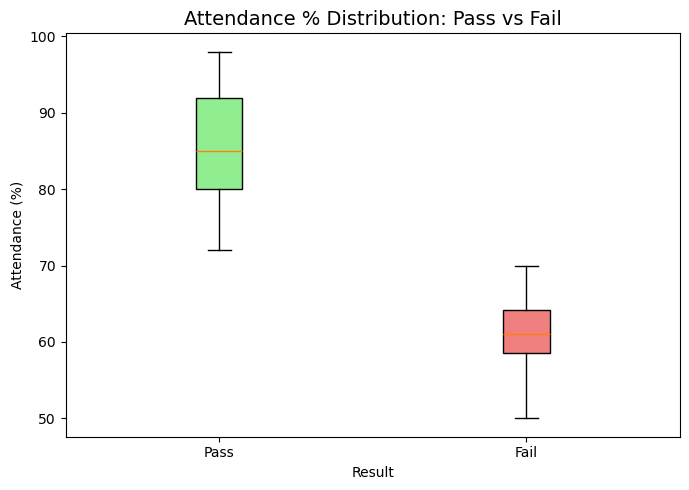

Saved: plot4_boxplot.png


In [25]:
# box plot — the box shows the middle 50% of attendance values
# the line in the middle of the box is the median
# whiskers extend to the min and max values

fig, ax = plt.subplots(figsize=(7, 5))

# extract attendance values for each group as plain lists
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

# patch_artist=True lets us fill the boxes with colour
bp = ax.boxplot([pass_attendance, fail_attendance],
                tick_labels=['Pass', 'Fail'], patch_artist=True)

# colour the two boxes differently so they are easy to distinguish
bp['boxes'][0].set_facecolor('lightgreen')
bp['boxes'][1].set_facecolor('lightcoral')

ax.set_title('Attendance % Distribution: Pass vs Fail', fontsize=14)
ax.set_xlabel('Result')
ax.set_ylabel('Attendance (%)')

plt.tight_layout()
plt.savefig('plot4_boxplot.png', dpi=100)
plt.show()
print("Saved: plot4_boxplot.png")

### Plot 5 — Line Plot: Math and Science Scores Per Student

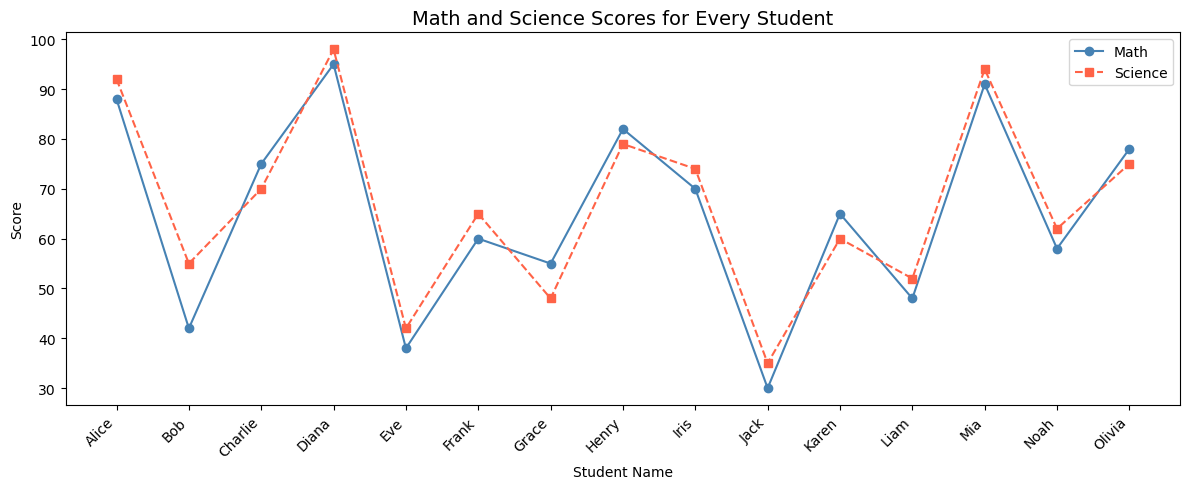

Saved: plot5_line.png


In [27]:
# line plot with one line for math and one for science
# each student is one point on the x-axis
# rotation=45 stops the 15 names from overlapping each other

fig, ax = plt.subplots(figsize=(12, 5))

names = df['name'].tolist()
x = range(len(names))

# different marker shapes and line styles make the two series easy to tell apart
ax.plot(x, df['math'].tolist(), marker='o', linestyle='-',
        color='steelblue', label='Math')
ax.plot(x, df['science'].tolist(), marker='s', linestyle='--',
        color='tomato', label='Science')

# set the x-axis tick positions and labels to the student names
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=45, ha='right')

ax.set_title('Math and Science Scores for Every Student', fontsize=14)
ax.set_xlabel('Student Name')
ax.set_ylabel('Score')
ax.legend()

plt.tight_layout()
plt.savefig('plot5_line.png', dpi=100)
plt.show()
print("Saved: plot5_line.png")

---
## Task 3 — Data Visualization with Seaborn

Two Seaborn plots saved as `.png` files and displayed inline.

### Plot 6 — Seaborn Bar Plot: Avg Math and Science Score by Pass/Fail

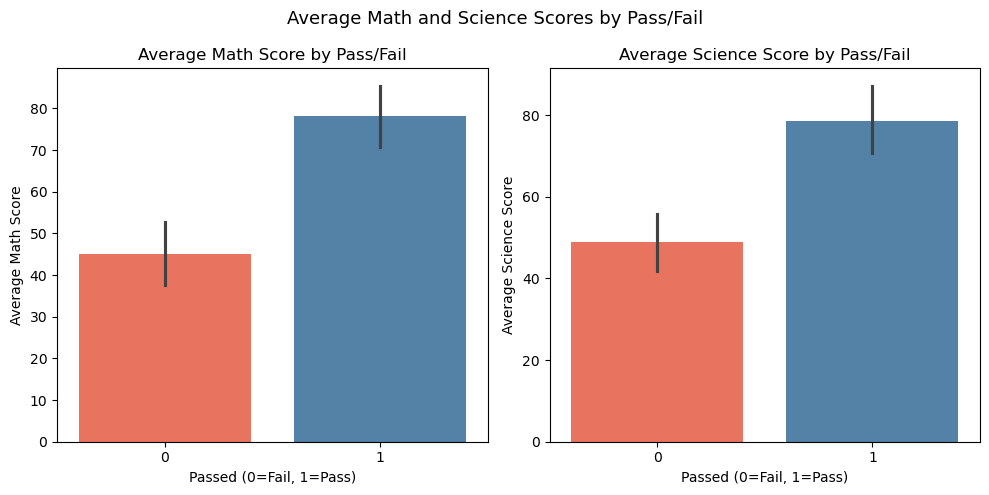

Saved: plot6_seaborn_bar.png


In [30]:
# two seaborn bar plots side by side — one for math, one for science
# split by passed (0=Fail, 1=Pass) so we can compare the two groups
# each call to sns.barplot() goes to a different subplot via the ax parameter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# left subplot: average math score for each group
sns.barplot(data=df, x='passed', y='math', hue='passed',
            palette={0: 'tomato', 1: 'steelblue'}, legend=False, ax=ax1)
ax1.set_title('Average Math Score by Pass/Fail')
ax1.set_xlabel('Passed (0=Fail, 1=Pass)')
ax1.set_ylabel('Average Math Score')

# right subplot: average science score for each group
sns.barplot(data=df, x='passed', y='science', hue='passed',
            palette={0: 'tomato', 1: 'steelblue'}, legend=False, ax=ax2)
ax2.set_title('Average Science Score by Pass/Fail')
ax2.set_xlabel('Passed (0=Fail, 1=Pass)')
ax2.set_ylabel('Average Science Score')

plt.suptitle('Average Math and Science Scores by Pass/Fail', fontsize=13)
plt.tight_layout()
plt.savefig('plot6_seaborn_bar.png', dpi=100)
plt.show()
print("Saved: plot6_seaborn_bar.png")

### Plot 7 — Seaborn Scatter + Regression Lines: Attendance vs Average Score

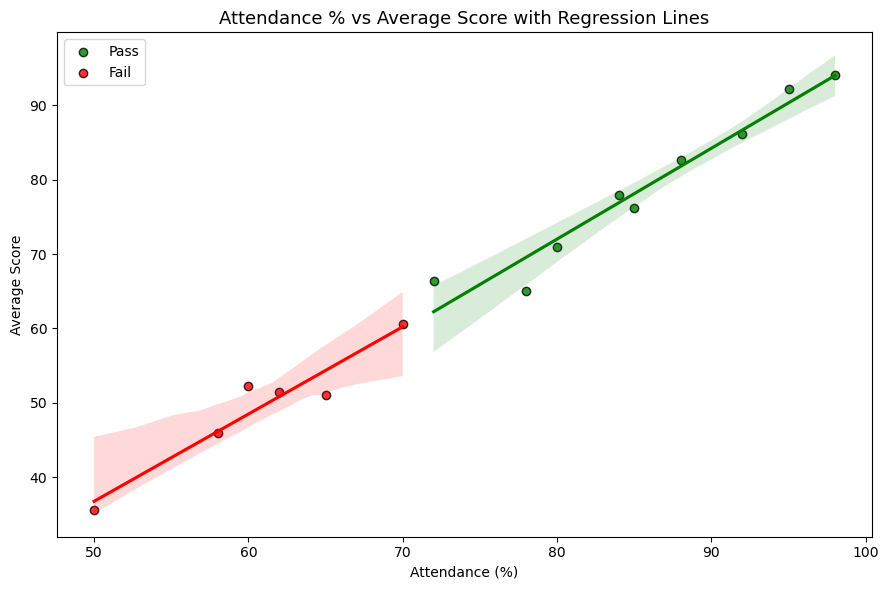

Saved: plot7_seaborn_scatter.png


In [32]:
# attendance_pct vs avg_score, coloured by pass/fail
# sns.regplot draws the scatter points AND a regression line automatically
# we call it twice so each group gets its own line and colour

fig, ax = plt.subplots(figsize=(9, 6))

# regression line for students who passed (green)
sns.regplot(data=df[df['passed'] == 1],
            x='attendance_pct', y='avg_score',
            label='Pass', color='green',
            scatter_kws={'edgecolors': 'black'}, ax=ax)

# regression line for students who failed (red)
sns.regplot(data=df[df['passed'] == 0],
            x='attendance_pct', y='avg_score',
            label='Fail', color='red',
            scatter_kws={'edgecolors': 'black'}, ax=ax)

ax.set_title('Attendance % vs Average Score with Regression Lines', fontsize=13)
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Average Score')
ax.legend()

plt.tight_layout()
plt.savefig('plot7_seaborn_scatter.png', dpi=100)
plt.show()
print("Saved: plot7_seaborn_scatter.png")

### Seaborn vs Matplotlib — Comparison

In [34]:
# ── Seaborn vs Matplotlib comparison ───────────────────────────────────────
#
# Seaborn was much easier for statistical plots like the grouped bar chart
# and the regression scatter plot — it handled the grouping, colour mapping,
# and regression line in just a couple of lines without any manual work.
#
# Matplotlib required more code for those same tasks (e.g. plotting two
# scatter groups separately, building legends manually) but gave us more
# control over things like bar colours, tick labels, and box fill colours.
#
# Overall: Seaborn is better for quick statistical exploration;
# Matplotlib is better when you need precise control over every visual detail.
#
# ────────────────────────────────────────────────────────────────────────────

print("Seaborn vs Matplotlib comparison written as comments above.")

Seaborn vs Matplotlib comparison written as comments above.


---
## Task 4 — Machine Learning with scikit-learn

### Step 1 — Prepare Data

In [37]:
# define the feature columns and target column
# we keep the original df intact — name is not dropped from df, only excluded from X

feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']

X = df[feature_cols]   # features (input)
y = df['passed']       # target (what we want to predict)

# split into 80% training and 20% test data
# random_state=42 makes the split the same every time we run this
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training set size:", len(X_train), "students")
print("Test set size:", len(X_test), "students")

# scale features using StandardScaler
# fit ONLY on training data to avoid data leakage into the test set
# then apply the same scaling to the test set using transform (not fit_transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled. Ready to train.")

Training set size: 12 students
Test set size: 3 students
Features scaled. Ready to train.


### Step 2 — Train a Logistic Regression Model

In [39]:
# logistic regression is a good starting point for binary classification
# it predicts a probability then converts it to 0 or 1 using a threshold
# max_iter=1000 gives the solver enough iterations to converge on this small dataset

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# training accuracy tells us how well the model fits the data it was trained on
train_acc = model.score(X_train_scaled, y_train)
print("Training accuracy:", str(round(train_acc * 100, 2)) + "%")

Training accuracy: 100.0%


### Step 3 — Evaluate on the Test Set

In [41]:
# predict labels for the 3 test students
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test accuracy:", str(round(test_acc * 100, 2)) + "%")
print("")

# X_test keeps its original DataFrame index after the split
# so df.loc[X_test.index, 'name'] gives us the correct student names
print("Predictions for each student in the test set:")

test_names = df.loc[X_test.index, 'name']

for name, actual, predicted in zip(test_names, y_test, y_pred):
    label_actual = "Pass" if actual == 1 else "Fail"
    label_pred = "Pass" if predicted == 1 else "Fail"
    result = "✅ correct" if actual == predicted else "❌ wrong"
    print(" ", name, "| Actual:", label_actual, "| Predicted:", label_pred, "|", result)

print("")
print("Note: with only 3 test students the accuracy will be 0%, 33%, 66% or 100%.")
print("The goal is to understand the workflow, not to optimise accuracy.")

Test accuracy: 100.0%

Predictions for each student in the test set:
  Jack | Actual: Fail | Predicted: Fail | ✅ correct
  Liam | Actual: Fail | Predicted: Fail | ✅ correct
  Alice | Actual: Pass | Predicted: Pass | ✅ correct

Note: with only 3 test students the accuracy will be 0%, 33%, 66% or 100%.
The goal is to understand the workflow, not to optimise accuracy.


### Step 4 — Feature Importance (Model Coefficients)

Feature coefficients (sorted by absolute value, largest first):
  english : 0.8125 -> Pass
  attendance_pct : 0.5219 -> Pass
  study_hours_per_day : 0.4844 -> Pass
  pe : 0.475 -> Pass
  math : 0.4379 -> Pass
  science : 0.323 -> Pass
  history : 0.2629 -> Pass


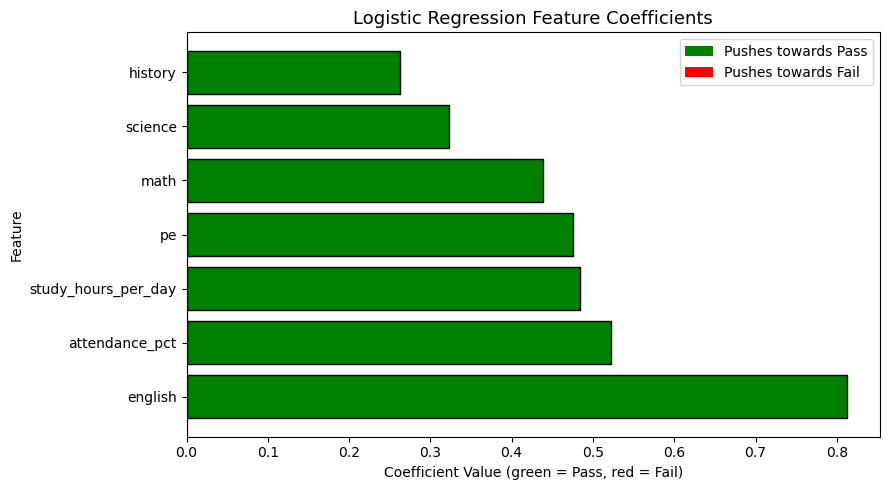

Saved: plot8_feature_importance.png


In [43]:
# model.coef_[0] gives one coefficient per feature
# a positive coefficient pushes the prediction towards Pass
# a negative coefficient pushes it towards Fail
# sorting by absolute value shows which features the model relies on most

coefficients = model.coef_[0]
coef_pairs = list(zip(feature_cols, coefficients))
coef_pairs.sort(key=lambda x: abs(x[1]), reverse=True)

print("Feature coefficients (sorted by absolute value, largest first):")
for feature, coef in coef_pairs:
    direction = "-> Pass" if coef > 0 else "-> Fail"
    print(" ", feature, ":", round(coef, 4), direction)

# horizontal bar chart — green = pushes towards Pass, red = pushes towards Fail
fig, ax = plt.subplots(figsize=(9, 5))

features_sorted = [x[0] for x in coef_pairs]
coefs_sorted = [x[1] for x in coef_pairs]
bar_colors = ['green' if c > 0 else 'red' for c in coefs_sorted]

ax.barh(features_sorted, coefs_sorted, color=bar_colors, edgecolor='black')

# vertical line at zero to clearly separate positive from negative
ax.axvline(0, color='black', linewidth=0.8)

ax.set_title('Logistic Regression Feature Coefficients', fontsize=13)
ax.set_xlabel('Coefficient Value (green = Pass, red = Fail)')
ax.set_ylabel('Feature')

legend_elements = [
    mpatches.Patch(facecolor='green', label='Pushes towards Pass'),
    mpatches.Patch(facecolor='red', label='Pushes towards Fail')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('plot8_feature_importance.png', dpi=100)
plt.show()
print("Saved: plot8_feature_importance.png")

### Step 5 (Bonus) — Predict for a New Student

In [45]:
# define a new student with values of our choice
# the order must exactly match feature_cols:
# [math, science, english, history, pe, attendance_pct, study_hours_per_day]

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# use scaler.transform (NOT fit_transform) — we apply the existing scale
# that was fitted on the training data
new_scaled = scaler.transform(new_student)

# model.predict returns 0 or 1
# model.predict_proba returns the probability of each class [P(Fail), P(Pass)]
prediction = model.predict(new_scaled)[0]
proba = model.predict_proba(new_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"

print("New student input:")
print("  math=75, science=70, english=68, history=65, pe=80,",
      "attendance=82%, study_hours=3.2")
print("")
print("Prediction:", result)
print("Probability -> Fail:", str(round(proba[0] * 100, 1)) + "%")
print("Probability -> Pass:", str(round(proba[1] * 100, 1)) + "%")

New student input:
  math=75, science=70, english=68, history=65, pe=80, attendance=82%, study_hours=3.2

Prediction: Pass
Probability -> Fail: 9.2%
Probability -> Pass: 90.8%


C:\Users\augus\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
